# Ergebnisse – Experiment-Summary
- Pro Experiment & Datensatz eine Tabelle (mit `n_runs` bei Exp 1/2/4); Bar-Chart bei Exp 1/2/4, bei Exp 3 SHAP-Tabelle + Bar-Charts (Top-Features und Text vs. numerisch)
- Quelle: alle MLflow-Runs aus `./mlruns`; fehlende/leere Experimente werden übersprungen

In [1]:
import os
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "result_tables"
DIAGRAM_DIR = "diagrams"
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(DIAGRAM_DIR, exist_ok=True)
DS_ABBR = {"fake_jobs": "fj", "airbnb_paris": "airbnb"}

## Runs laden
- Nur vorhandene Experimente aus `./mlruns`; leere/fehlende werden übersprungen

In [2]:
mlflow.set_tracking_uri("file:./mlruns")

experiments = [f"{ds}_experiment_{i}" for ds in ["fake_jobs", "airbnb_paris"] for i in [1, 2, 3, 4]]

parts = []
for name in experiments:
    exp = mlflow.get_experiment_by_name(name)
    if exp is None:
        continue
    runs = mlflow.search_runs([exp.experiment_id])
    if len(runs) == 0:
        continue
    runs["experiment"] = name
    parts.append(runs)

df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
print(f"{len(df)} Runs aus {len(parts)} Experimenten geladen")

/home/debian/TFM_master_thesis/.venv/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


440 Runs aus 8 Experimenten geladen


## Aufbereiten
- Datensatz / Experiment-Nr. / Modellname ableiten; Metrik-Spalten vereinheitlichen

In [3]:
datasets = ["fake_jobs", "airbnb_paris"]

if len(df):
    df["exp_num"] = df["experiment"].str.split("_").str[-1].astype(int)
    df["dataset"] = df["experiment"].str.rsplit("_experiment_", n=1).str[0]
    df["model"] = df["tags.mlflow.runName"] if "tags.mlflow.runName" in df.columns else df["run_id"]
    df = df[df["model"] != "contexttab_fixed"]  # veralteten Run ausschließen
    df = df.rename(columns={"metrics.auprc": "AUPRC", "metrics.auc_roc": "AUROC", "metrics.runtime_s": "runtime_s"})
    for col in ["AUPRC", "AUROC", "runtime_s"]:
        if col not in df.columns:
            df[col] = np.nan
    print("Datensätze:", df["dataset"].unique().tolist(), "| Experimente:", sorted(df["exp_num"].unique()))

Datensätze: ['fake_jobs', 'airbnb_paris'] | Experimente: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Experiment 1 – Unsupervised Outlier Detection
- TFMs (TabPFN unsup., AnoLLM, FoMo-OD) vs. PyOD-Baselines; AUPRC & AUROC je Modell als Mittelwert ± Standardabweichung
- Tabelle je Datensatz; je 1 kombinierter Chart für AUPRC, AUROC und Runtime (beide Datensätze, Modelle alphabetisch)

=== Experiment 1 – fake_jobs (Mittelwert ± Std) ===


,AUPRC,AUROC,runtime_s,n_runs
model,,,,
anollm,0.1005 ± 0.0013,0.6306 ± 0.0016,8113.3125 ± 1193.0984,3
iforest,0.0890 ± 0.0000,0.6125 ± 0.0000,2.4863 ± 0.0789,3
autoencoder,0.0816 ± 0.0000,0.6003 ± 0.0000,180.9683 ± 9.7396,3
ecod,0.0745 ± 0.0000,0.6125 ± 0.0000,0.4611 ± 0.0211,3
fomo_od,0.0624 ± 0.0000,0.6040 ± 0.0000,0.4328 ± 0.0373,3
tabpfn_unsup,0.0619 ± 0.0013,0.5252 ± 0.0067,356.9191 ± 6.1042,3
loda,0.0526 ± 0.0085,0.5185 ± 0.0327,0.4901 ± 0.0041,3


=== Experiment 1 – airbnb_paris (Mittelwert ± Std) ===


,AUPRC,AUROC,runtime_s,n_runs
model,,,,
ecod,0.0920 ± 0.0000,0.7213 ± 0.0000,0.6743 ± 0.0462,3
iforest,0.0832 ± 0.0000,0.7060 ± 0.0000,2.3030 ± 0.0634,3
loda,0.0607 ± 0.0081,0.5507 ± 0.0502,0.5940 ± 0.0684,3
tabpfn_unsup,0.0597 ± 0.0030,0.6434 ± 0.0044,1443.7897 ± 21.1196,3
autoencoder,0.0578 ± 0.0000,0.6029 ± 0.0000,188.9135 ± 4.5965,3
anollm,0.0485 ± 0.0003,0.5960 ± 0.0022,9606.8165 ± 838.9814,3
fomo_od,0.0414 ± 0.0000,0.5182 ± 0.0000,0.4001 ± 0.0848,3


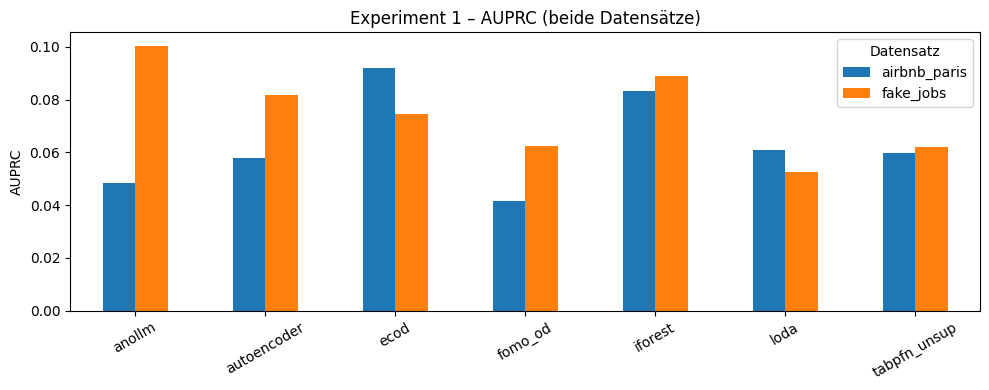

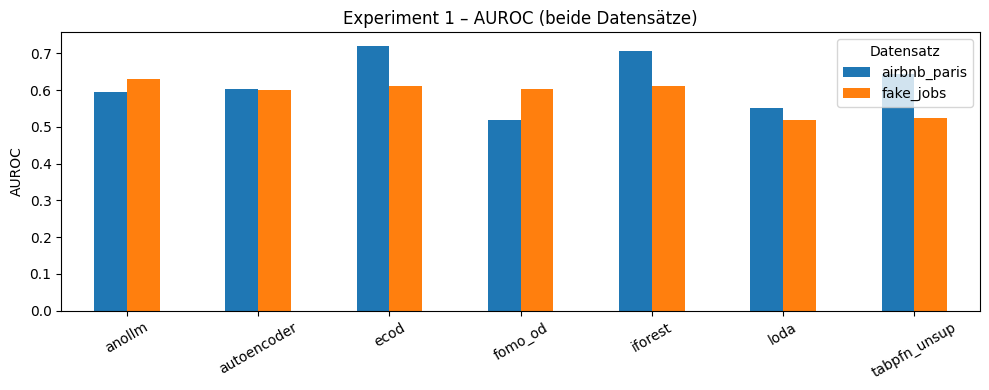

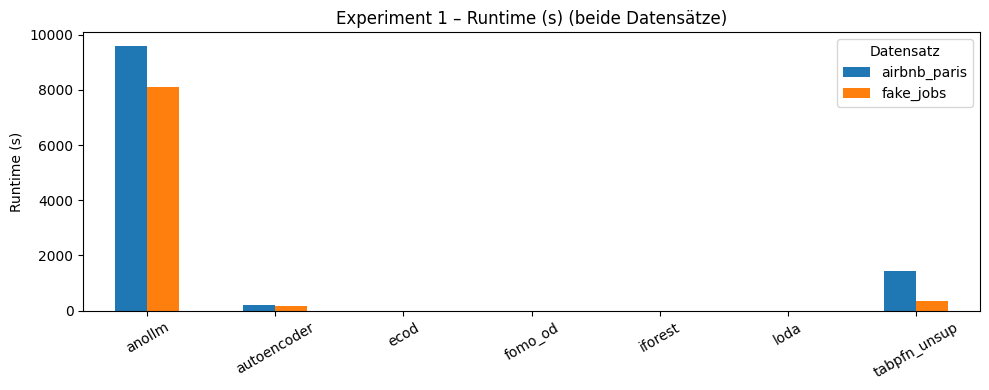

In [4]:
sub = df[df["exp_num"] == 1] if len(df) else df
if not len(sub):
    print("keine Exp-1-Runs")
else:
    # Tabelle je Datensatz: Mittelwert ± Standardabweichung
    for ds in datasets:
        s = sub[sub["dataset"] == ds]
        if not len(s):
            continue
        g = s.groupby("model")
        mean = g[["AUPRC", "AUROC", "runtime_s"]].mean()
        std = g[["AUPRC", "AUROC", "runtime_s"]].std().fillna(0)  # std eines Einzel-Runs -> 0
        order = mean["AUPRC"].sort_values(ascending=False).index
        disp = (mean.map("{:.4f}".format) + " ± " + std.map("{:.4f}".format)).loc[order]
        tex = (mean.map("{:.4f}".format) + " $\\pm$ " + std.map("{:.4f}".format)).loc[order]
        disp.to_csv(f"{RESULT_DIR}/exp1_{ds}.csv")  # n_runs nur zur Anzeige, nicht speichern
        # scientific-style .tex: booktabs (hrules) + fette Spaltenheader
        sty = (tex.style.format(escape=None)
               .format_index(escape="latex", axis="index").format_index(escape="latex", axis="columns")
               .map_index(lambda v: "font-weight: bold;", axis="columns")
               .hide(axis="index", names=True).hide(axis="columns", names=True))
        sty.to_latex(f"{RESULT_DIR}/exp1_{ds}.tex", hrules=True, convert_css=True, position_float="centering",
                     caption=f"Experiment 1 -- Unsupervised Outlier Detection ({ds.replace('_', ' ')}): AUPRC, AUROC und Laufzeit je Modell (Mittelwert $\\pm$ Standardabweichung).", label=f"tab:exp1_{ds}")
        show = disp.copy()
        show["n_runs"] = g.size().loc[order].astype(int)
        print(f"=== Experiment 1 – {ds} (Mittelwert ± Std) ===")
        display(show)

    # je 1 Chart (beide Datensätze, Modelle alphabetisch) -> diagrams/
    for metric, label, fname in [("AUPRC", "AUPRC", "auprc"), ("AUROC", "AUROC", "auroc"), ("runtime_s", "Runtime (s)", "runtime")]:
        piv = sub.pivot_table(index="model", columns="dataset", values=metric, aggfunc="mean").sort_index()
        ax = piv.plot.bar(figsize=(10, 4), rot=30)
        ax.set_title(f"Experiment 1 – {label} (beide Datensätze)")
        ax.set_ylabel(label)
        ax.set_xlabel("")
        ax.legend(title="Datensatz")
        plt.tight_layout()
        plt.savefig(f"{DIAGRAM_DIR}/exp1_{fname}.png", facecolor='white', edgecolor='white', dpi=300)
        plt.savefig(f"{DIAGRAM_DIR}/exp1_{fname}.pdf", facecolor='white', edgecolor='white')
        plt.show()
        plt.close()

## Experiment 2 – Enhanced Baseline-Modelle
- Baselines auf cleaned vs. semantisch vs. fastText vs. enhanced vs. enhanced+semantisch
- Je Datensatz je 1 Tabelle für AUPRC und AUROC (Detektor × Repräsentation, Mittelwert ± Standardabweichung) + je 1 Chart
- Hinweis: enhanced ist semi-supervised (Label-Leakage), nicht direkt mit unsupervised vergleichbar

=== Experiment 2 – fake_jobs: AUPRC (Mittelwert ± Std) je Detektor × Repräsentation ===


params.representation,cleaned,semantic_pca30,semantic_pca100,fast_text_pca30,fast_text_pca100,enhanced,enhanced_pca30,enhanced_semantic_pca30
params.detector,,,,,,,,
autoencoder,0.0816 ± 0.0000,0.0696 ± 0.0000,0.0573 ± 0.0000,0.0742 ± 0.0000,0.0760 ± 0.0000,0.1793 ± 0.0000,0.0849 ± 0.0000,0.0919 ± 0.0000
ecod,0.0745 ± 0.0000,0.0580 ± 0.0000,0.0457 ± 0.0000,0.0812 ± 0.0000,0.0768 ± 0.0000,0.1142 ± 0.0000,0.1074 ± 0.0000,0.0814 ± 0.0000
iforest,0.0858 ± 0.0000,0.0842 ± 0.0000,0.0564 ± 0.0005,0.0902 ± 0.0000,0.0780 ± 0.0000,0.1130 ± 0.0000,0.1453 ± 0.0000,0.1101 ± 0.0019
loda,0.0603 ± 0.0210,0.0384 ± 0.0000,0.0448 ± 0.0000,0.0486 ± 0.0000,0.0531 ± 0.0000,0.1503 ± 0.0000,0.1208 ± 0.0000,0.0445 ± 0.0000


=== Experiment 2 – fake_jobs: AUROC (Mittelwert ± Std) je Detektor × Repräsentation ===


params.representation,cleaned,semantic_pca30,semantic_pca100,fast_text_pca30,fast_text_pca100,enhanced,enhanced_pca30,enhanced_semantic_pca30
params.detector,,,,,,,,
autoencoder,0.6003 ± 0.0000,0.5856 ± 0.0000,0.5283 ± 0.0002,0.6445 ± 0.0000,0.6162 ± 0.0000,0.8102 ± 0.0000,0.6453 ± 0.0000,0.6777 ± 0.0000
ecod,0.6125 ± 0.0000,0.5503 ± 0.0000,0.4903 ± 0.0000,0.6258 ± 0.0000,0.6247 ± 0.0000,0.7516 ± 0.0000,0.6975 ± 0.0000,0.6579 ± 0.0000
iforest,0.6141 ± 0.0000,0.6197 ± 0.0000,0.5384 ± 0.0007,0.6523 ± 0.0000,0.6450 ± 0.0000,0.7312 ± 0.0000,0.7071 ± 0.0000,0.6787 ± 0.0006
loda,0.5151 ± 0.0500,0.4303 ± 0.0000,0.4832 ± 0.0000,0.5005 ± 0.0000,0.5127 ± 0.0000,0.8037 ± 0.0000,0.7154 ± 0.0000,0.5056 ± 0.0000


--- fake_jobs: n_runs je Detektor × Repräsentation ---


params.representation,cleaned,semantic_pca30,semantic_pca100,fast_text_pca30,fast_text_pca100,enhanced,enhanced_pca30,enhanced_semantic_pca30
params.detector,,,,,,,,
autoencoder,6,6,6,3,3,6,6,6
ecod,6,6,6,3,3,6,6,6
iforest,6,6,6,3,3,6,6,6
loda,6,6,6,3,3,6,6,6


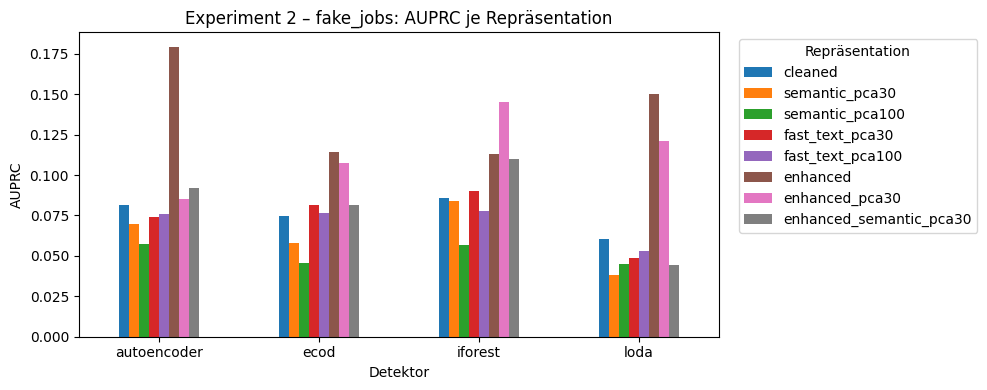

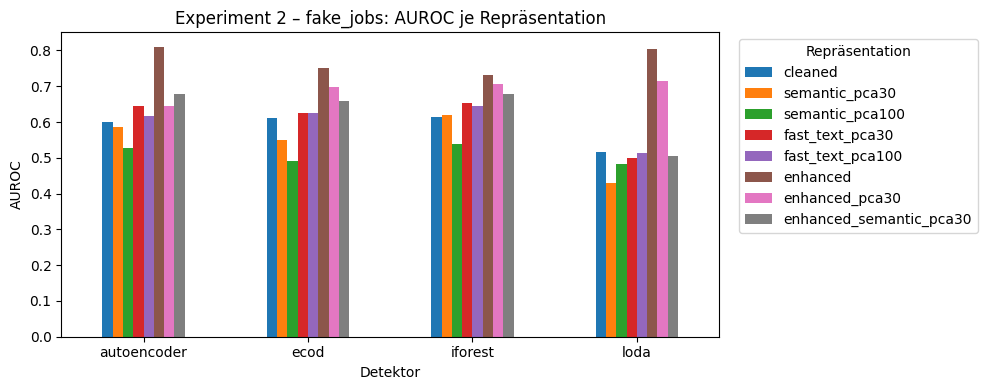

=== Experiment 2 – airbnb_paris: AUPRC (Mittelwert ± Std) je Detektor × Repräsentation ===


params.representation,cleaned,semantic_pca30,semantic_pca100,fast_text_pca30,fast_text_pca100,enhanced,enhanced_pca30,enhanced_semantic_pca30
params.detector,,,,,,,,
autoencoder,0.0709 ± 0.0002,0.0506 ± 0.0000,0.0433 ± 0.0001,0.0524 ± 0.0000,0.0456 ± 0.0000,0.2296 ± 0.0000,0.1298 ± 0.0000,0.1424 ± 0.0000
ecod,0.1058 ± 0.0000,0.0821 ± 0.0000,0.0651 ± 0.0000,0.0860 ± 0.0000,0.0584 ± 0.0000,0.0598 ± 0.0000,0.2697 ± 0.0000,0.1434 ± 0.0000
iforest,0.0867 ± 0.0000,0.0785 ± 0.0001,0.0675 ± 0.0000,0.0882 ± 0.0000,0.0682 ± 0.0000,0.1234 ± 0.0000,0.2291 ± 0.0000,0.1012 ± 0.0000
loda,0.0904 ± 0.0090,0.0657 ± 0.0000,0.0504 ± 0.0000,0.0687 ± 0.0000,0.0683 ± 0.0000,0.0760 ± 0.0000,0.1919 ± 0.0000,0.0627 ± 0.0000


=== Experiment 2 – airbnb_paris: AUROC (Mittelwert ± Std) je Detektor × Repräsentation ===


params.representation,cleaned,semantic_pca30,semantic_pca100,fast_text_pca30,fast_text_pca100,enhanced,enhanced_pca30,enhanced_semantic_pca30
params.detector,,,,,,,,
autoencoder,0.6110 ± 0.0003,0.5230 ± 0.0000,0.5005 ± 0.0004,0.5589 ± 0.0000,0.5536 ± 0.0000,0.7742 ± 0.0000,0.7148 ± 0.0000,0.6637 ± 0.0000
ecod,0.7240 ± 0.0000,0.6733 ± 0.0000,0.6141 ± 0.0000,0.7002 ± 0.0000,0.6365 ± 0.0000,0.6290 ± 0.0000,0.7455 ± 0.0000,0.7620 ± 0.0000
iforest,0.6962 ± 0.0000,0.6622 ± 0.0009,0.6116 ± 0.0000,0.6887 ± 0.0000,0.6709 ± 0.0000,0.6681 ± 0.0000,0.7569 ± 0.0000,0.7306 ± 0.0000
loda,0.6619 ± 0.0309,0.5937 ± 0.0000,0.5150 ± 0.0000,0.5619 ± 0.0000,0.5589 ± 0.0000,0.6854 ± 0.0000,0.7299 ± 0.0000,0.5384 ± 0.0000


--- airbnb_paris: n_runs je Detektor × Repräsentation ---


params.representation,cleaned,semantic_pca30,semantic_pca100,fast_text_pca30,fast_text_pca100,enhanced,enhanced_pca30,enhanced_semantic_pca30
params.detector,,,,,,,,
autoencoder,7,7,7,4,4,7,7,7
ecod,7,7,7,4,4,7,7,7
iforest,7,7,7,4,4,7,7,7
loda,7,7,7,4,4,7,7,7


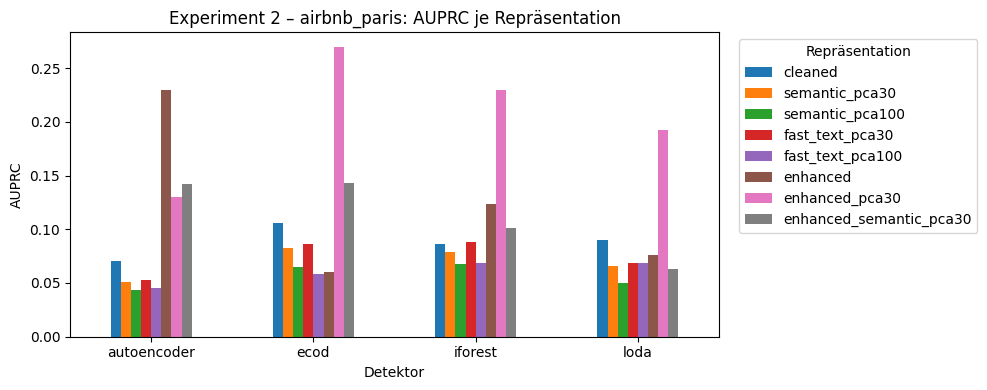

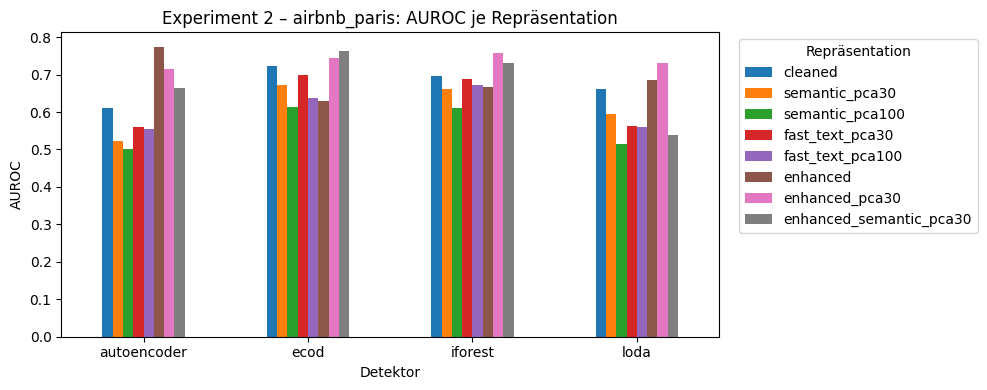

In [5]:
# feste Repräsentations-Reihenfolge (fastText neben den semantic-Analoga)
REP_ORDER = ["cleaned", "semantic_pca30", "semantic_pca100", "fast_text_pca30", "fast_text_pca100", "enhanced", "enhanced_pca30", "enhanced_semantic_pca30"]
# AUPRC behält den alten Dateinamen (exp2_<ds>), AUROC bekommt einen eigenen (exp2_auroc_<ds>)
FILE_STEM = {"AUPRC": "exp2", "AUROC": "exp2_auroc"}

for ds in datasets:
    sub = df[(df["exp_num"] == 2) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-2-Runs")
        continue
    reps = sub["params.representation"].unique().tolist()
    order = [r for r in REP_ORDER if r in reps] + [r for r in reps if r not in REP_ORDER]  # unbekannte Reps ans Ende

    # AUPRC- und AUROC-Tabelle: Mittelwert ± Std je Detektor × Repräsentation
    for metric in ["AUPRC", "AUROC"]:
        m = sub.pivot_table(index="params.detector", columns="params.representation", values=metric, aggfunc="mean").reindex(columns=order)
        sd = sub.pivot_table(index="params.detector", columns="params.representation", values=metric, aggfunc="std").reindex(index=m.index, columns=order).fillna(0)
        disp = (m.map("{:.4f}".format) + " ± " + sd.map("{:.4f}".format)).where(m.notna(), "--")
        tex = (m.map("{:.4f}".format) + " $\\pm$ " + sd.map("{:.4f}".format)).where(m.notna(), "--")
        disp.to_csv(f"{RESULT_DIR}/{FILE_STEM[metric]}_{ds}.csv")
        # scientific-style .tex: booktabs (hrules) + fette Spaltenheader
        sty = (tex.style.format(escape=None)
               .format_index(escape="latex", axis="index").format_index(escape="latex", axis="columns")
               .map_index(lambda v: "font-weight: bold;", axis="columns")
               .hide(axis="index", names=True).hide(axis="columns", names=True))
        sty.to_latex(f"{RESULT_DIR}/{FILE_STEM[metric]}_{ds}.tex", hrules=True, convert_css=True, position_float="centering",
                     caption=f"Experiment 2 -- Enhanced Baselines ({ds.replace('_', ' ')}): {metric} je Detektor und Repräsentation (Mittelwert $\\pm$ Standardabweichung).", label=f"tab:{FILE_STEM[metric]}_{ds}")
        print(f"=== Experiment 2 – {ds}: {metric} (Mittelwert ± Std) je Detektor × Repräsentation ===")
        display(disp)

    # n_runs zur Kontrolle
    n = sub.pivot_table(index="params.detector", columns="params.representation", values="AUPRC", aggfunc="size").reindex(columns=order)
    print(f"--- {ds}: n_runs je Detektor × Repräsentation ---")
    display(n)

    # AUPRC je Detektor × Repräsentation -> diagrams/
    piv_auprc = sub.pivot_table(index="params.detector", columns="params.representation", values="AUPRC", aggfunc="mean").reindex(columns=order)
    ax = piv_auprc.plot.bar(figsize=(10, 4), rot=0)
    ax.set_title(f"Experiment 2 – {ds}: AUPRC je Repräsentation")
    ax.set_ylabel("AUPRC")
    ax.set_xlabel("Detektor")
    ax.legend(title="Repräsentation", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/exp2_auprc_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
    plt.savefig(f"{DIAGRAM_DIR}/exp2_auprc_{DS_ABBR[ds]}.pdf", facecolor='white', edgecolor='white')
    plt.show()
    plt.close()

    # AUROC je Detektor × Repräsentation -> diagrams/
    piv_auroc = sub.pivot_table(index="params.detector", columns="params.representation", values="AUROC", aggfunc="mean").reindex(columns=order)
    ax = piv_auroc.plot.bar(figsize=(10, 4), rot=0)
    ax.set_title(f"Experiment 2 – {ds}: AUROC je Repräsentation")
    ax.set_ylabel("AUROC")
    ax.set_xlabel("Detektor")
    ax.legend(title="Repräsentation", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/exp2_auroc_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
    plt.savefig(f"{DIAGRAM_DIR}/exp2_auroc_{DS_ABBR[ds]}.pdf", facecolor='white', edgecolor='white')
    plt.show()
    plt.close()

## Experiment 3 – Semantische Relevanz (SHAP)
- ConTextTab-SHAP: wichtigste Features je Datensatz (Tabelle + Bar-Charts: Top-Features und Text vs. numerisch)

=== Exp 3 – fake_jobs: Top 20 Features (Text + numerisch) ===


,mean_abs_shap,type
company_profile,0.1373,text
has_company_logo,0.0547,numeric
title,0.0503,text
description,0.0354,text
has_questions,0.0310,numeric
requirements,0.0286,text
salary_avg,0.0265,numeric
country,0.0150,numeric
benefits,0.0136,text
industry,0.0116,numeric


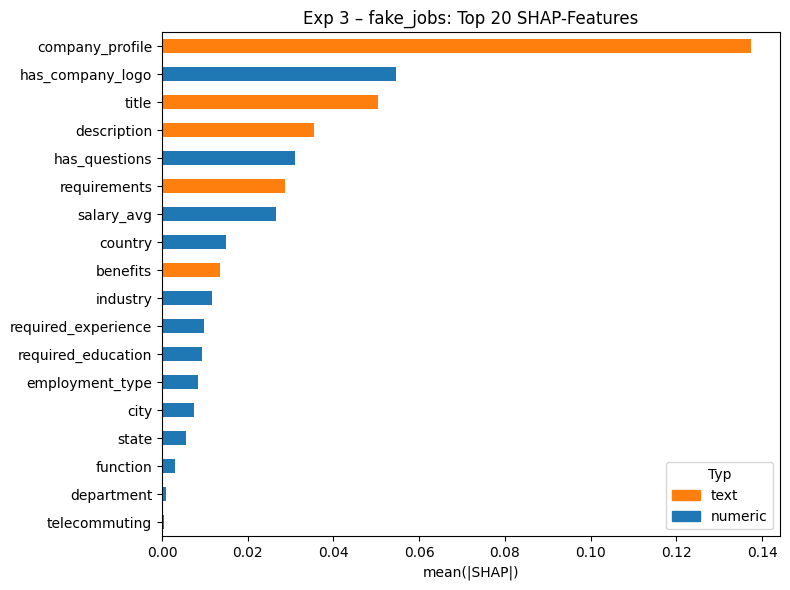

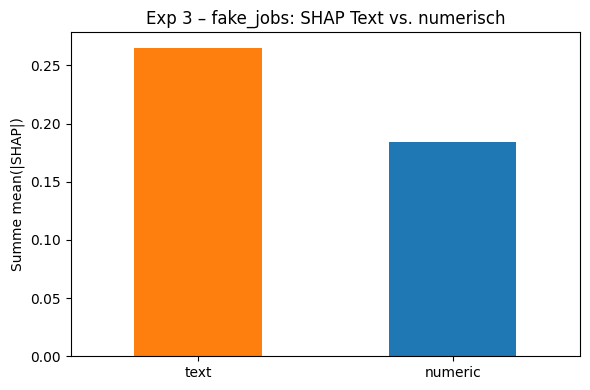

=== Exp 3 – airbnb_paris: Top 20 Features (Text + numerisch) ===


,mean_abs_shap,type
host_tenure_days,0.0352,numeric
name,0.0352,text
estimated_occupancy_l365d,0.0276,numeric
calculated_host_listings_count,0.0265,numeric
host_is_superhost,0.0216,numeric
calculated_host_listings_count_entire_homes,0.0180,numeric
description,0.0170,text
minimum_nights,0.0163,numeric
instant_bookable,0.0162,numeric
accommodates,0.0147,numeric


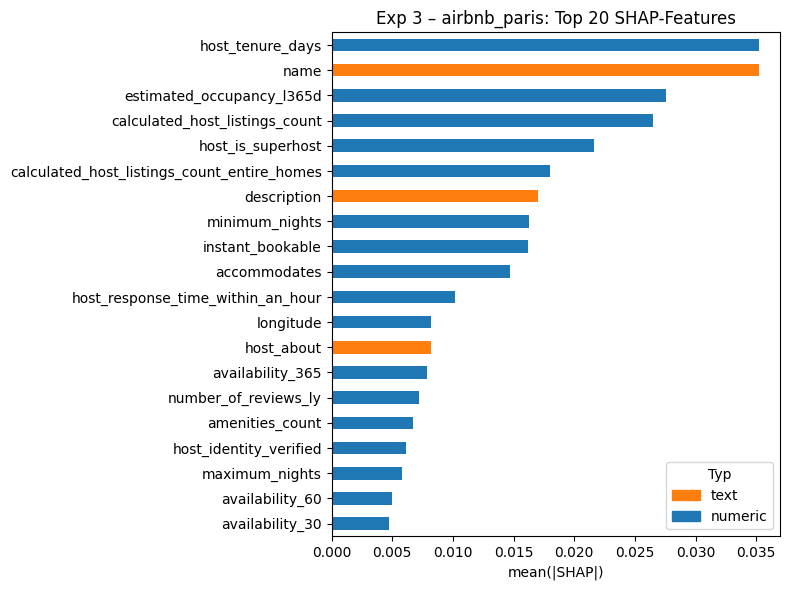

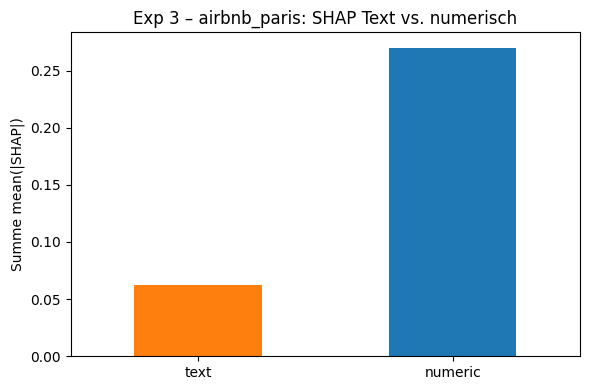

In [6]:
for ds in datasets:
    sub = df[(df["exp_num"] == 3) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        continue
    rel_cols = [c for c in sub.columns if c.startswith("metrics.") and not c.endswith("_total") and sub[c].notna().any()]
    rel = sub.iloc[0][rel_cols].dropna().astype(float)
    rel.index = [c.replace("metrics.", "") for c in rel.index]
    rel_type = pd.Series(["text" if i.startswith("text_") else "numeric" for i in rel.index], index=rel.index)
    top = rel.sort_values(ascending=False).head(20).round(4).to_frame("mean_abs_shap")
    top["type"] = [rel_type[i] for i in top.index]
    top.index = [i.replace("text_", "").replace("num_", "") for i in top.index]
    top.to_csv(f"{RESULT_DIR}/exp3_{ds}.csv")
    # scientific-style .tex: booktabs (hrules) + fette Spaltenheader
    sty = (top.style.format(precision=4, escape="latex")
           .format_index(escape="latex", axis="index").format_index(escape="latex", axis="columns")
           .map_index(lambda v: "font-weight: bold;", axis="columns")
           .hide(axis="index", names=True).hide(axis="columns", names=True))
    sty.to_latex(f"{RESULT_DIR}/exp3_{ds}.tex", hrules=True, convert_css=True, position_float="centering",
                 caption=f"Experiment 3 -- Semantische Relevanz ({ds.replace('_', ' ')}): Top-20 SHAP-Features (Text und numerisch).", label=f"tab:exp3_{ds}")
    print(f"=== Exp 3 – {ds}: Top 20 Features (Text + numerisch) ===")
    display(top)

    # bar chart: top features colored by type
    colors = {"text": "tab:orange", "numeric": "tab:blue"}
    ax = top["mean_abs_shap"][::-1].plot.barh(figsize=(8, 6), color=[colors[t] for t in top["type"][::-1]])
    ax.set_title(f"Exp 3 – {ds}: Top 20 SHAP-Features")
    ax.set_xlabel("mean(|SHAP|)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[t]) for t in ["text", "numeric"]]
    ax.legend(handles, ["text", "numeric"], title="Typ")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/exp3_shap_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
    plt.savefig(f"{DIAGRAM_DIR}/exp3_shap_{DS_ABBR[ds]}.pdf", facecolor='white', edgecolor='white')
    plt.show()
    plt.close()

    # second chart: total SHAP contribution text vs numeric
    by_type = rel.groupby(rel_type).sum().reindex(["text", "numeric"]).fillna(0).round(4)
    ax = by_type.plot.bar(figsize=(6, 4), rot=0, color=[colors[t] for t in by_type.index])
    ax.set_title(f"Exp 3 – {ds}: SHAP Text vs. numerisch")
    ax.set_ylabel("Summe mean(|SHAP|)")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/exp3_shap_sum_{DS_ABBR[ds]}.png", facecolor='white', edgecolor='white', dpi=300)
    plt.savefig(f"{DIAGRAM_DIR}/exp3_shap_sum_{DS_ABBR[ds]}.pdf", facecolor='white', edgecolor='white')
    plt.show()
    plt.close()

## Experiment 4 – TFMs zur binären Klassifikation
- ConTextTab vs. TabPFN-Klassifikation; AUPRC & AUROC je Modell als Mittelwert ± Standardabweichung
- Je Modell zwei `distribution`-Varianten (`original`, `balanced_1to4`) als eigene Runs (`*_original` / `*_balanced_1to4`)
- Tabelle je Datensatz; je 1 kombinierter Chart für AUPRC und AUROC (beide Datensätze, Modelle alphabetisch)

=== Experiment 4 – fake_jobs (Mittelwert ± Std) ===


,AUPRC,AUROC,runtime_s,n_runs
model,,,,
contexttab_balanced_1to4,0.9144 ± 0.0000,0.9651 ± 0.0000,2.7600 ± 0.6248,3
contexttab_original,0.9039 ± 0.0000,0.9912 ± 0.0000,31.6167 ± 6.7346,3
tabpfn_classification_balanced_1to4,0.8345 ± 0.0000,0.9439 ± 0.0000,2.2233 ± 0.1582,3
tabpfn_classification_original,0.7195 ± 0.0000,0.9332 ± 0.0000,4.6000 ± 1.3202,3


=== Experiment 4 – airbnb_paris (Mittelwert ± Std) ===


,AUPRC,AUROC,runtime_s,n_runs
model,,,,
tabpfn_classification_balanced_1to4,0.6103 ± 0.0000,0.8556 ± 0.0000,2.5267 ± 0.0902,3
contexttab_balanced_1to4,0.5845 ± 0.0000,0.8761 ± 0.0000,2.1400 ± 0.0656,3
tabpfn_classification_original,0.2030 ± 0.0000,0.8681 ± 0.0000,8.0067 ± 0.2268,3
contexttab_original,0.1816 ± 0.0000,0.8596 ± 0.0000,54.7100 ± 1.0034,3


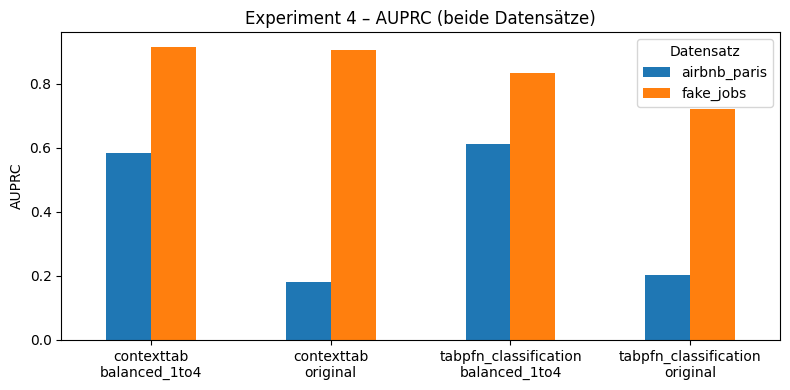

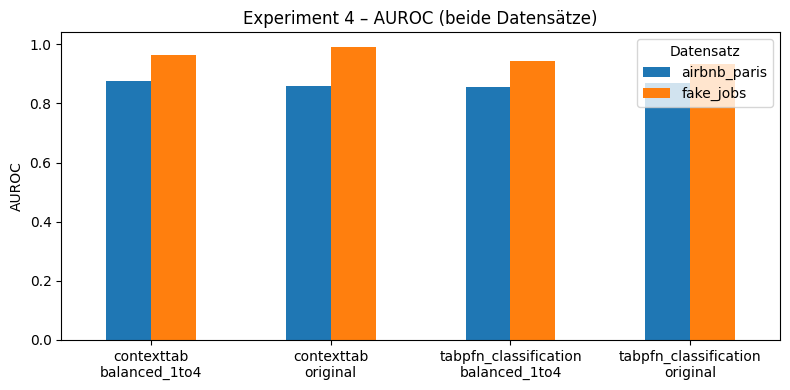

In [7]:
sub = df[df["exp_num"] == 4] if len(df) else df
if not len(sub):
    print("keine Exp-4-Runs")
else:
    # Tabelle je Datensatz: Mittelwert ± Standardabweichung
    for ds in datasets:
        s = sub[sub["dataset"] == ds]
        if not len(s):
            continue
        g = s.groupby("model")
        mean = g[["AUPRC", "AUROC", "runtime_s"]].mean()
        std = g[["AUPRC", "AUROC", "runtime_s"]].std().fillna(0)  # std eines Einzel-Runs -> 0
        order = mean["AUPRC"].sort_values(ascending=False).index
        disp = (mean.map("{:.4f}".format) + " ± " + std.map("{:.4f}".format)).loc[order]
        tex = (mean.map("{:.4f}".format) + " $\\pm$ " + std.map("{:.4f}".format)).loc[order]
        disp.to_csv(f"{RESULT_DIR}/exp4_{ds}.csv")  # n_runs nur zur Anzeige, nicht speichern
        # scientific-style .tex: booktabs (hrules) + fette Spaltenheader
        sty = (tex.style.format(escape=None)
               .format_index(escape="latex", axis="index").format_index(escape="latex", axis="columns")
               .map_index(lambda v: "font-weight: bold;", axis="columns")
               .hide(axis="index", names=True).hide(axis="columns", names=True))
        sty.to_latex(f"{RESULT_DIR}/exp4_{ds}.tex", hrules=True, convert_css=True, position_float="centering",
                     caption=f"Experiment 4 -- TFM-Klassifikation ({ds.replace('_', ' ')}): AUPRC, AUROC und Laufzeit je Modell (Mittelwert $\\pm$ Standardabweichung).", label=f"tab:exp4_{ds}")
        show = disp.copy()
        show["n_runs"] = g.size().loc[order].astype(int)
        print(f"=== Experiment 4 – {ds} (Mittelwert ± Std) ===")
        display(show)

    # AUPRC- & AUROC-Chart (beide Datensätze) -> diagrams/
    for metric, label, fname in [("AUPRC", "AUPRC", "auprc"), ("AUROC", "AUROC", "auroc")]:
        piv = sub.pivot_table(index="model", columns="dataset", values=metric, aggfunc="mean").sort_index()
        # Modellname und distribution-Variante auf zwei Zeilen
        piv.index = [m.replace("_balanced_", "\nbalanced_").replace("_original", "\noriginal") for m in piv.index]
        ax = piv.plot.bar(figsize=(8, 4), rot=0)
        ax.set_title(f"Experiment 4 – {label} (beide Datensätze)")
        ax.set_ylabel(label)
        ax.set_xlabel("")
        ax.legend(title="Datensatz")
        plt.tight_layout()
        plt.savefig(f"{DIAGRAM_DIR}/exp4_{fname}.png", facecolor='white', edgecolor='white', dpi=300)
        plt.savefig(f"{DIAGRAM_DIR}/exp4_{fname}.pdf", facecolor='white', edgecolor='white')
        plt.show()
        plt.close()